
Uniform
----------------------------------------
Sample Mean       : 4.9941
Theoretical Mean  : 5.0000
Sample Variance   : 8.3550
Theoretical Var   : 8.3333

Normal
----------------------------------------
Sample Mean       : 50.0445
Theoretical Mean  : 50.0000
Sample Variance   : 98.5139
Theoretical Var   : 100.0000

Binomial
----------------------------------------
Sample Mean       : 5.9804
Theoretical Mean  : 6.0000
Sample Variance   : 4.1514
Theoretical Var   : 4.2000

Poisson
----------------------------------------
Sample Mean       : 3.9940
Theoretical Mean  : 4.0000
Sample Variance   : 3.9930
Theoretical Var   : 4.0000

Exponential
----------------------------------------
Sample Mean       : 1.9839
Theoretical Mean  : 2.0000
Sample Variance   : 3.8951
Theoretical Var   : 4.0000

Poisson Check
----------------------------------------
Sample Mean     : 3.9940
Sample Variance : 3.9930
Theoretical λ   : 4


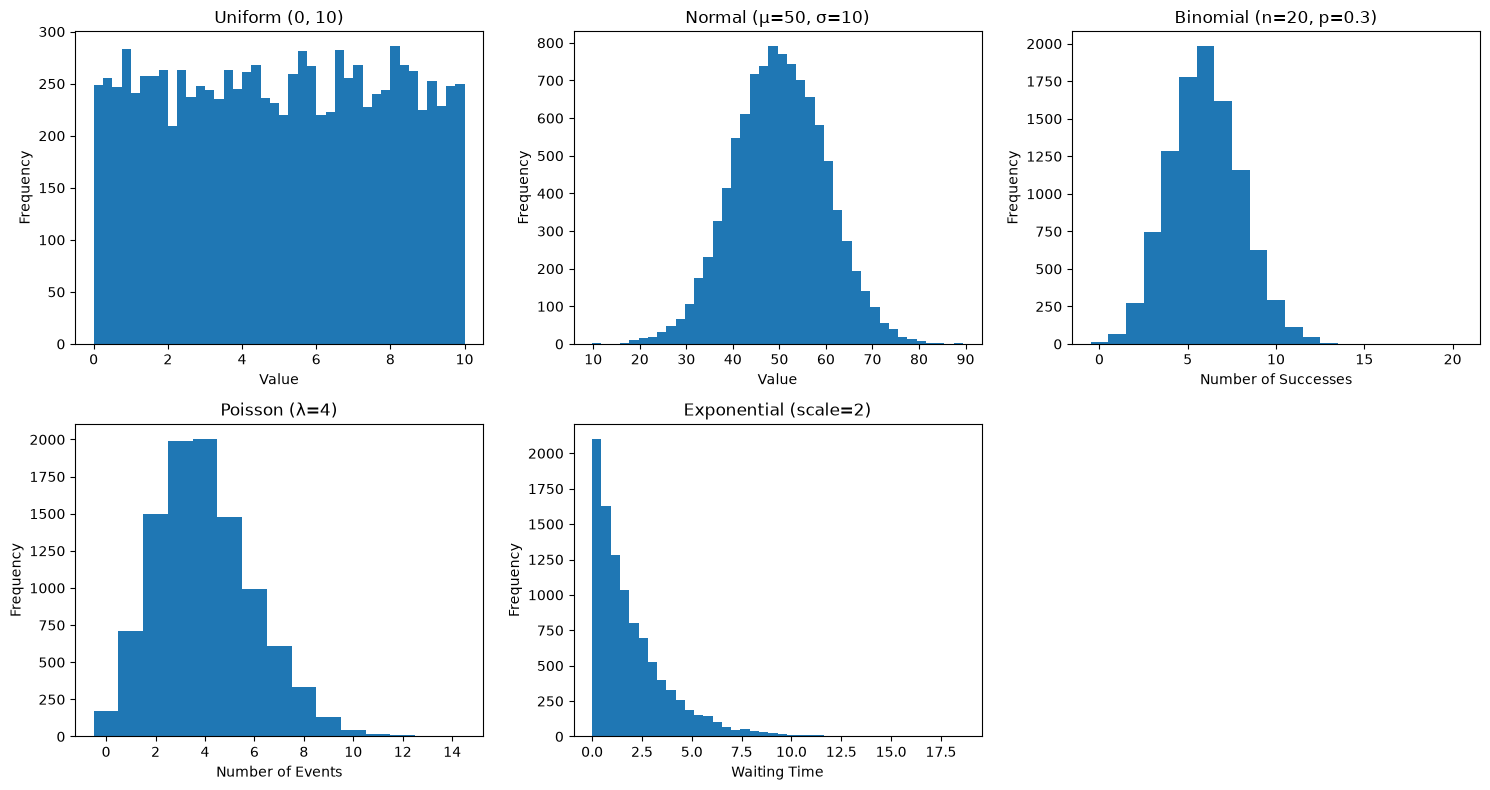

In [1]:

# TASK 01 — SAMPLE AND CHARACTERISE FIVE DISTRIBUTIONS

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fixed seed -> same random results every time we run the code
rng = np.random.default_rng(0)

# Number of samples for every distribution
N = 10_000

# 1. PARAMETERS

# Uniform distribution: values between a and b
a, b = 0, 10

# Normal distribution: mean and standard deviation
mu, sigma = 50, 10

# Binomial distribution: number of trials and success probability
n, p = 20, 0.3

# Poisson distribution: average number of events
lam = 4

# Exponential distribution: scale = average waiting time
scale = 2

# 2. GENERATE 10,000 SAMPLES

uniform = rng.uniform(a, b, N)
normal = rng.normal(mu, sigma, N)
binomial = rng.binomial(n, p, N)
poisson = rng.poisson(lam, N)
exponential = rng.exponential(scale, N)

# 3. THEORETICAL MEAN AND VARIANCE

theoretical = {
    "Uniform": {
        "mean": (a + b) / 2,
        "variance": (b - a) ** 2 / 12
    },

    "Normal": {
        "mean": mu,
        "variance": sigma ** 2
    },

    "Binomial": {
        "mean": n * p,
        "variance": n * p * (1 - p)
    },

    "Poisson": {
        "mean": lam,
        "variance": lam
    },

    "Exponential": {
        "mean": scale,
        "variance": scale ** 2
    }
}

# 4. SAMPLE MEAN & VARIANCE VS THEORETICAL VALUES

samples = {
    "Uniform": uniform,
    "Normal": normal,
    "Binomial": binomial,
    "Poisson": poisson,
    "Exponential": exponential
}

for name, data in samples.items():

    # Calculate statistics from our actual 10,000 samples
    sample_mean = data.mean()
    sample_variance = data.var()

    # Get the theoretical values
    theory_mean = theoretical[name]["mean"]
    theory_variance = theoretical[name]["variance"]

    print(f"\n{name}")
    print("-" * 40)
    print(f"Sample Mean       : {sample_mean:.4f}")
    print(f"Theoretical Mean  : {theory_mean:.4f}")
    print(f"Sample Variance   : {sample_variance:.4f}")
    print(f"Theoretical Var   : {theory_variance:.4f}")

# 5. CONFIRM POISSON PROPERTY

print("\nPoisson Check")
print("-" * 40)
print(f"Sample Mean     : {poisson.mean():.4f}")
print(f"Sample Variance : {poisson.var():.4f}")
print(f"Theoretical λ   : {lam}")

# For Poisson distribution:
# Theoretical Mean = λ
# Theoretical Variance = λ
# Therefore Mean = Variance

# 6. PLOT ALL FIVE HISTOGRAMS

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Uniform
axes[0, 0].hist(uniform, bins=40)
axes[0, 0].set_title("Uniform (0, 10)")
axes[0, 0].set_xlabel("Value")
axes[0, 0].set_ylabel("Frequency")

# Normal
axes[0, 1].hist(normal, bins=40)
axes[0, 1].set_title("Normal (μ=50, σ=10)")
axes[0, 1].set_xlabel("Value")
axes[0, 1].set_ylabel("Frequency")

# Binomial
# Integer-centered bins make the discrete values easier to see.
axes[0, 2].hist(
    binomial,
    bins=np.arange(-0.5, n + 1.5, 1)
)
axes[0, 2].set_title("Binomial (n=20, p=0.3)")
axes[0, 2].set_xlabel("Number of Successes")
axes[0, 2].set_ylabel("Frequency")

# Poisson
axes[1, 0].hist(
    poisson,
    bins=np.arange(-0.5, max(poisson) + 1.5, 1)
)
axes[1, 0].set_title("Poisson (λ=4)")
axes[1, 0].set_xlabel("Number of Events")
axes[1, 0].set_ylabel("Frequency")


# Exponential
axes[1, 1].hist(exponential, bins=40)
axes[1, 1].set_title("Exponential (scale=2)")
axes[1, 1].set_xlabel("Waiting Time")
axes[1, 1].set_ylabel("Frequency")


# We only need five plots, so hide the sixth subplot.
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Task 01 — Lookup Questions & Observations

## 1. Theoretical Mean and Variance

### Uniform Distribution

Parameters:
- a = 0
- b = 10

Theoretical Mean:

Mean = (a + b) / 2

= (0 + 10) / 2

= 5

Theoretical Variance:

Variance = (b - a)² / 12

= (10 - 0)² / 12

= 8.3333

---

### Normal Distribution

Parameters:
- μ = 50
- σ = 10

Theoretical Mean:

Mean = μ = 50

Theoretical Variance:

Variance = σ²

= 10²

= 100

---

### Binomial Distribution

Parameters:
- n = 20
- p = 0.3

Theoretical Mean:

Mean = np

= 20 × 0.3

= 6

Theoretical Variance:

Variance = np(1 - p)

= 20 × 0.3 × 0.7

= 4.2

---

### Poisson Distribution

Parameter:
- λ = 4

Theoretical Mean:

Mean = λ = 4

Theoretical Variance:

Variance = λ = 4

Therefore:

Mean = Variance = 4

This is the important Poisson signature.

---

### Exponential Distribution

Parameter:
- scale = 2

Theoretical Mean:

Mean = scale = 2

Theoretical Variance:

Variance = scale²

= 2²

= 4


# 2. Distribution Classification

| Distribution | Type | Bounded? | Range |
|---|---|---|---|
| Uniform | Continuous | Yes | 0 to 10 |
| Normal | Continuous | No | -∞ to +∞ |
| Binomial | Discrete | Yes | 0 to 20 |
| Poisson | Discrete | No | 0 to ∞ |
| Exponential | Continuous | No | 0 to ∞ |


# 3. What does each distribution model?

### Uniform
Models a random quantity where every value within a fixed interval is equally likely.

### Normal
Models quantities that tend to cluster around an average value, such as measurement errors.

### Binomial
Models the number of successes in a fixed number of independent trials.

Example: Number of customers who purchase out of 20 customers.

### Poisson
Models the number of events occurring during a fixed time or space interval.

Example: Number of customer calls received in one minute.

### Exponential
Models the waiting time until the next event occurs.

Example: Time until the next customer arrives.


# 4. Required Observations

### Uniform
The histogram should be approximately flat because values between 0 and 10 have equal probability.

### Normal
The histogram should have a bell-shaped curve centered around 50.

### Binomial
The distribution is discrete and bounded between 0 and 20 because there can be at most 20 successes.

### Poisson
The distribution is discrete and its theoretical mean and variance are both λ = 4.

Therefore:

Mean = Variance

### Exponential
The distribution is continuous and strongly right-skewed. Most observations are small and there is a long right tail.


# 5. Why are Sample Mean and Variance not exactly equal to Theory?

The samples are randomly generated and contain a finite number of observations.

Therefore, the sample statistics may be slightly different from the theoretical values.

With 10,000 samples, they should be reasonably close to the theoretical values.


# 6. Final Answers

### Which distributions are discrete?

- Binomial
- Poisson

### Which distributions are continuous?

- Uniform
- Normal
- Exponential

### Which distributions are bounded?

- Uniform
- Binomial

### Which distributions are unbounded?

- Normal
- Poisson
- Exponential

